In [2]:
##import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
##Chargement & Visualisation
dataset = pd.read_csv("../data/mnist.csv")
print(dataset.shape)
dataset.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
##vérification des doublons
dataset.drop_duplicates()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


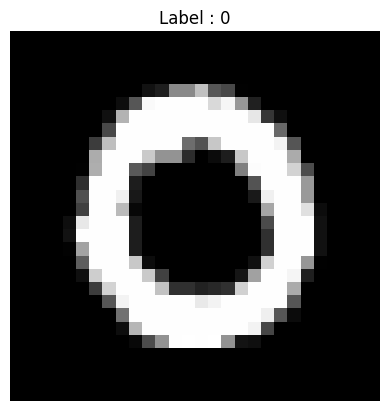

In [4]:
##Affichage d'un exemple
exemple = dataset.iloc[1]
pixels = exemple.drop("label").values
image = pixels.reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Label : {int(exemple['label'])}")
plt.show()

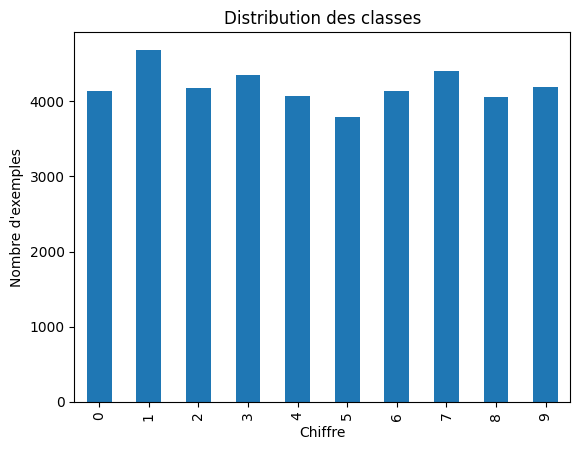

In [6]:
##Distribution des classes
label_counts = dataset["label"].value_counts().sort_index()
label_counts.plot(kind="bar")
plt.title("Distribution des classes")
plt.xlabel("Chiffre")
plt.ylabel("Nombre d'exemples")
plt.show()

In [8]:
##Préparation des données
X = dataset.drop("label", axis=1).values / 255.0
Y = dataset["label"].values

indice = int(0.8 * len(dataset))
X_train, X_test = X[:indice], X[indice:]
Y_train_raw, Y_test = Y[:indice], Y[indice:]

# One-Hot Encoding
def one_hot(y, n_classes=10):
    m = len(y)
    Y_oh = np.zeros((m, n_classes))
    Y_oh[np.arange(m), y] = 1
    return Y_oh

Y_train = one_hot(Y_train_raw)
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape},  Y_test:  {Y_test.shape}")

X_train: (33600, 784), Y_train: (33600, 10)
X_test:  (8400, 784),  Y_test:  (8400,)


In [10]:
##Fonctions du modèle 
def softmax(z):
    # Stabilité numérique : soustraire le max
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

def forward(X, W, b):
    z = np.dot(X, W) + b
    return softmax(z)

def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    log_probs = -np.log(y_pred + 1e-9)  # clip pour éviter log(0)
    return np.sum(y_true * log_probs) / m

def gradient(X, y_pred, y_true):
    m = X.shape[0]
    dz = y_pred - y_true
    dW = np.dot(X.T, dz) / m
    db = np.sum(dz, axis=0, keepdims=True) / m
    return dW, db

def update(W, b, dW, db, lr):
    return W - lr * dW, b - lr * db

Epoch    0 | Loss = 2.3271
Epoch  100 | Loss = 0.6059
Epoch  200 | Loss = 0.4858
Epoch  300 | Loss = 0.4362
Epoch  400 | Loss = 0.4075


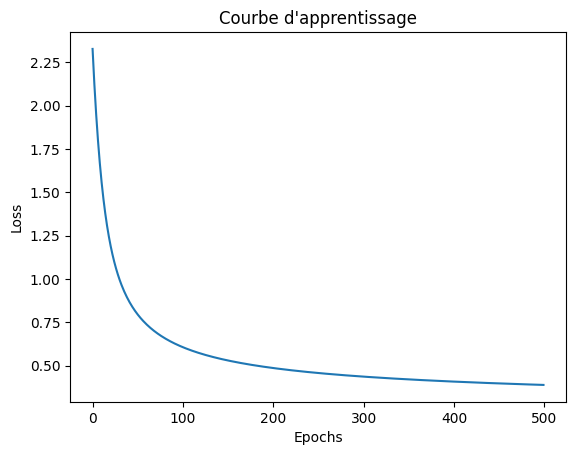

In [11]:
##Entraînement
np.random.seed(42)
pixels, n_classes = 784, 10
W = np.random.randn(pixels, n_classes) * 0.01
b = np.zeros((1, n_classes))

lr = 0.1
epochs = 500
losses = []

for i in range(epochs):
    y_pred = forward(X_train, W, b)
    l = cross_entropy_loss(y_pred, Y_train)
    losses.append(l)
    dW, db = gradient(X_train, y_pred, Y_train)
    W, b = update(W, b, dW, db, lr)
    if i % 100 == 0:
        print(f"Epoch {i:>4} | Loss = {l:.4f}")

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Courbe d'apprentissage")
plt.savefig("../outputs/learning_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
##Evaluation
y_pred_test = forward(X_test, W, b)
predictions = np.argmax(y_pred_test, axis=1)
accuracy = np.mean(predictions == Y_test)
print(f"Accuracy : {accuracy * 100:.2f}%")

Accuracy : 89.70%


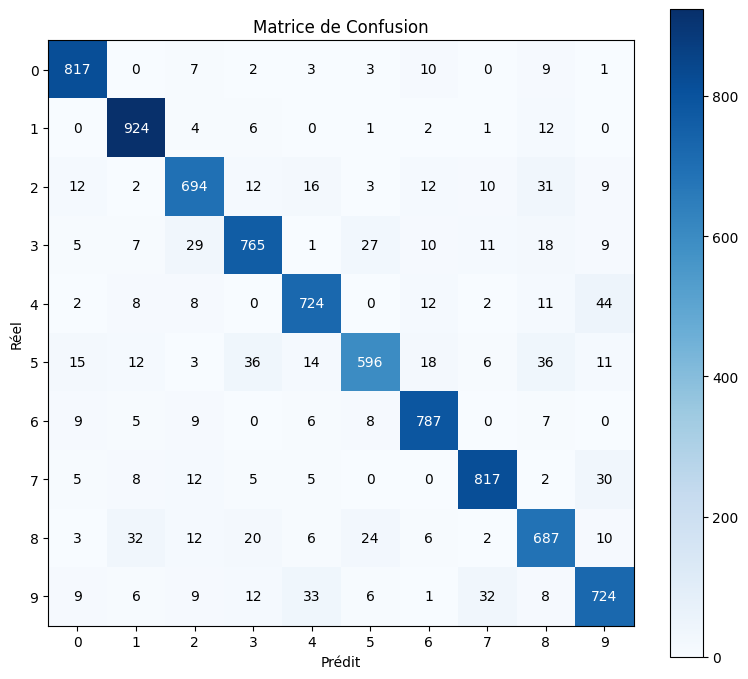

In [13]:
##Matrice de confusion
cm = np.zeros((10, 10), dtype=int)
for vrai, pred in zip(Y_test, predictions):
    cm[vrai][pred] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de Confusion")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()